In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_parquet(
    "/home/ed/Desktop/TS-Forecasting/data/green_tripdata_2026-01.parquet"
)

df.head()

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,cbd_congestion_fee
0,1,2026-01-01 00:27:58,2026-01-01 00:55:16,N,1.0,65,233,2.0,6.20,31.7,...,1.5,7.5,0.0,NaN,1.0,45.20,1.0,1.0,2.75,0.75
1,2,2026-01-01 00:44:33,2026-01-01 01:32:56,N,5.0,66,188,5.0,5.36,50.0,...,0.0,10.2,0.0,NaN,1.0,61.20,1.0,2.0,0.00,0.00
2,1,2026-01-01 00:23:45,2026-01-01 00:45:03,N,1.0,65,179,4.0,10.60,41.5,...,1.5,2.0,0.0,NaN,1.0,46.00,1.0,1.0,0.00,0.00
3,1,2026-01-01 00:44:33,2026-01-01 01:00:45,N,1.0,42,141,1.0,4.20,19.8,...,1.5,0.0,0.0,NaN,1.0,25.05,2.0,1.0,2.75,0.00
4,2,2026-01-01 00:46:04,2026-01-01 01:04:40,N,1.0,95,82,1.0,2.76,19.1,...,0.5,0.0,0.0,NaN,1.0,21.60,2.0,1.0,0.00,0.00


In [2]:
print("="*80)
print("Green TAXI DATASET")
print("="*80)

# -------------------------
# BASIC INFO
# -------------------------

print("\nShape")
print(df.shape)

print("\nColumns")
print(df.columns.tolist())

print("\nData Types")
print(df.dtypes)

print("\nMemory Usage MB")
print(round(df.memory_usage(deep=True).sum()/1024**2,2))


Green TAXI DATASET

Shape
(40272, 21)

Columns
['VendorID', 'lpep_pickup_datetime', 'lpep_dropoff_datetime', 'store_and_fwd_flag', 'RatecodeID', 'PULocationID', 'DOLocationID', 'passenger_count', 'trip_distance', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'ehail_fee', 'improvement_surcharge', 'total_amount', 'payment_type', 'trip_type', 'congestion_surcharge', 'cbd_congestion_fee']

Data Types
VendorID                          int32
lpep_pickup_datetime     datetime64[us]
lpep_dropoff_datetime    datetime64[us]
store_and_fwd_flag                  str
RatecodeID                      float64
PULocationID                      int32
DOLocationID                      int32
passenger_count                 float64
trip_distance                   float64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
ehail_fee            


Missing Values
                       Missing  Percent
ehail_fee                40272   100.00
trip_type                 5415    13.45
passenger_count           5414    13.44
store_and_fwd_flag        5414    13.44
RatecodeID                5414    13.44
congestion_surcharge      5414    13.44
payment_type              5414    13.44
VendorID                     0     0.00
lpep_dropoff_datetime        0     0.00
lpep_pickup_datetime         0     0.00
PULocationID                 0     0.00
DOLocationID                 0     0.00
trip_distance                0     0.00
tip_amount                   0     0.00
mta_tax                      0     0.00
extra                        0     0.00
fare_amount                  0     0.00
total_amount                 0     0.00
improvement_surcharge        0     0.00
tolls_amount                 0     0.00
cbd_congestion_fee           0     0.00


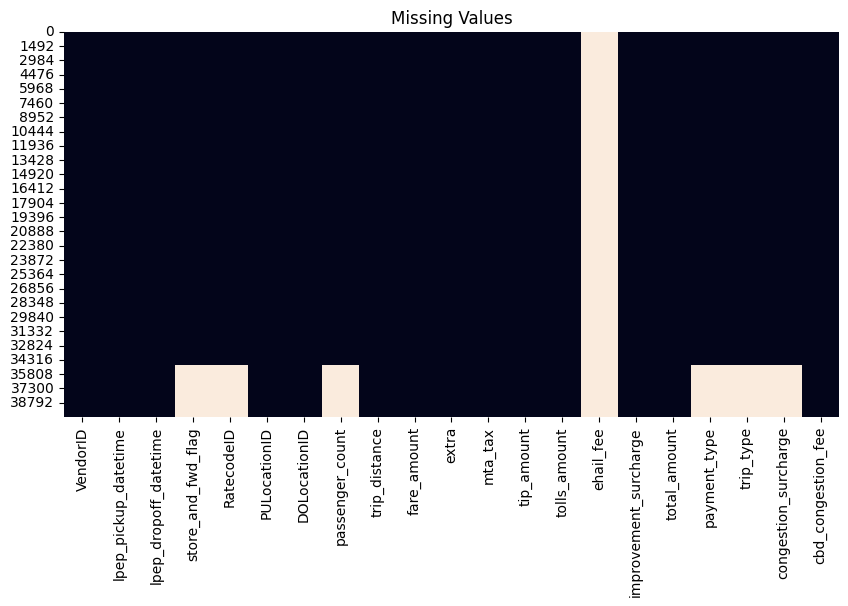

In [42]:
# -------------------------
# MISSING VALUES
# -------------------------

missing = pd.DataFrame({
    "Missing":df.isnull().sum(),
    "Percent":round(df.isnull().mean()*100,2)
})

print("\nMissing Values")
print(missing.sort_values(
    "Percent",
    ascending=False
))

plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(),cbar=False)
plt.title("Missing Values")
plt.show()


In [43]:
# -------------------------
# DUPLICATES
# -------------------------

print("\nDuplicates")
print(df.duplicated().sum())

# -------------------------
# DESCRIPTIVE STATS
# -------------------------

print(df.describe())



Duplicates
0
           VendorID        lpep_pickup_datetime       lpep_dropoff_datetime  \
count  40272.000000                       40272                       40272   
mean       2.279897  2026-01-16 22:38:57.806366  2026-01-16 22:59:02.332389   
min        1.000000         2025-12-27 16:49:41         2025-12-27 17:02:11   
25%        2.000000         2026-01-09 11:18:24  2026-01-09 11:37:25.250000   
50%        2.000000  2026-01-16 14:27:16.500000  2026-01-16 14:47:26.500000   
75%        2.000000  2026-01-23 19:37:11.500000  2026-01-23 19:55:24.250000   
max        6.000000         2026-02-01 21:08:36         2026-02-01 21:15:02   
std        1.233095                         NaN                         NaN   

         RatecodeID  PULocationID  DOLocationID  passenger_count  \
count  34858.000000  40272.000000  40272.000000     34858.000000   
mean       1.207212     96.190480    141.878352         1.298382   
min        1.000000      1.000000      1.000000         0.000000   
25

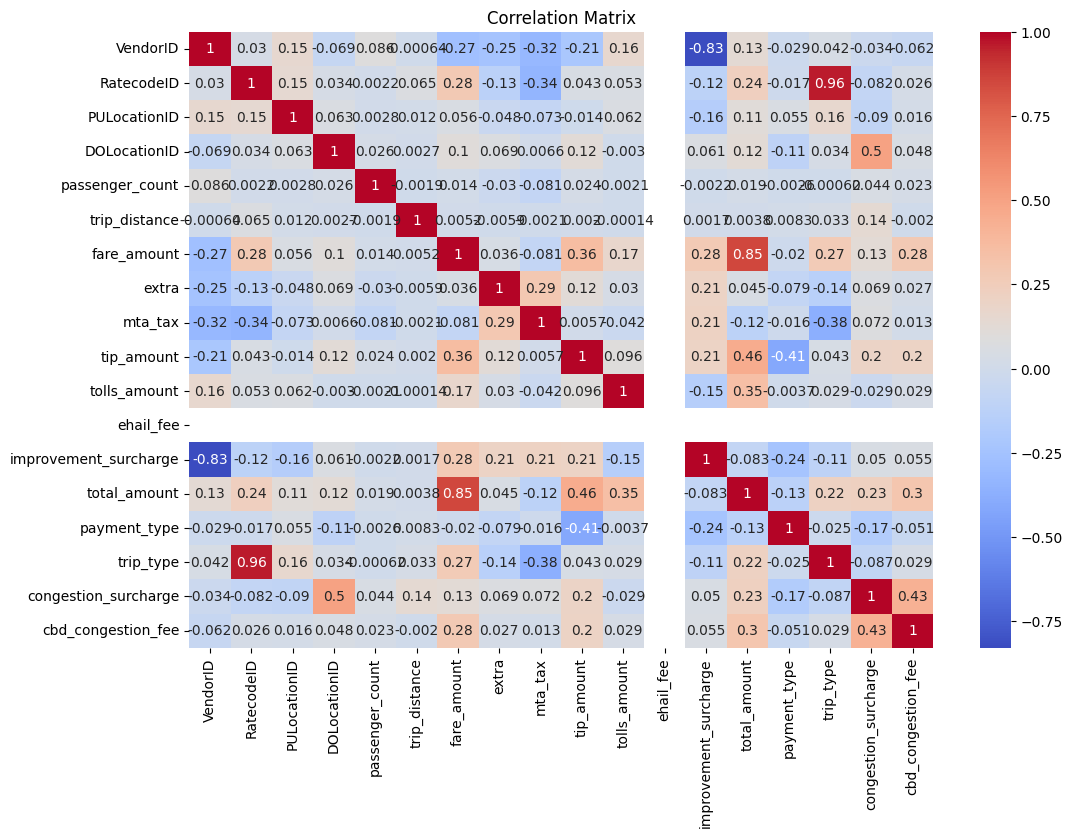

In [44]:
# -------------------------
# CORRELATION
# -------------------------

numeric_cols = df.select_dtypes(
    include=np.number
)

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()

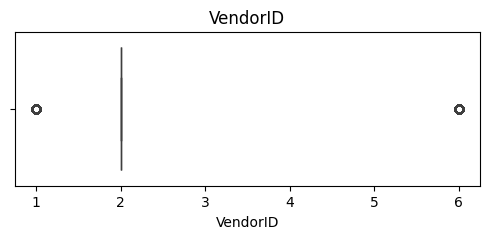

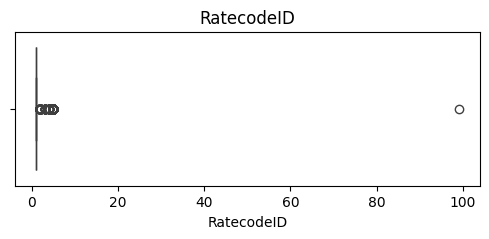

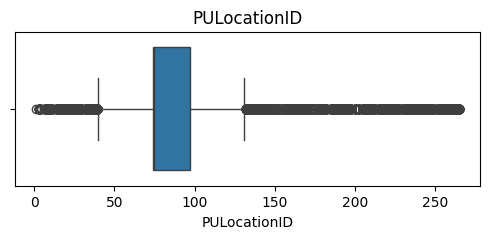

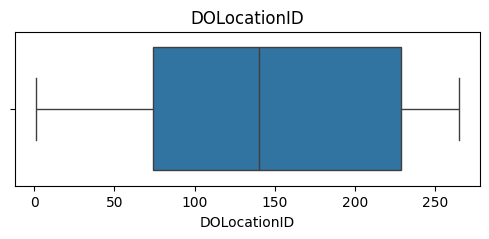

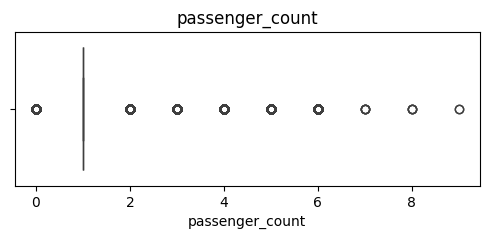

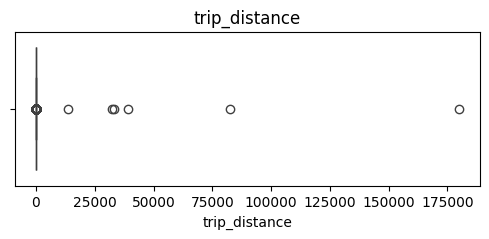

In [45]:
# -------------------------
# OUTLIERS
# -------------------------

for col in numeric_cols.columns[:6]:

    plt.figure(figsize=(6,2))

    sns.boxplot(
        x=df[col]
    )

    plt.title(col)

    plt.show()


Unique Pickup Zones:
235


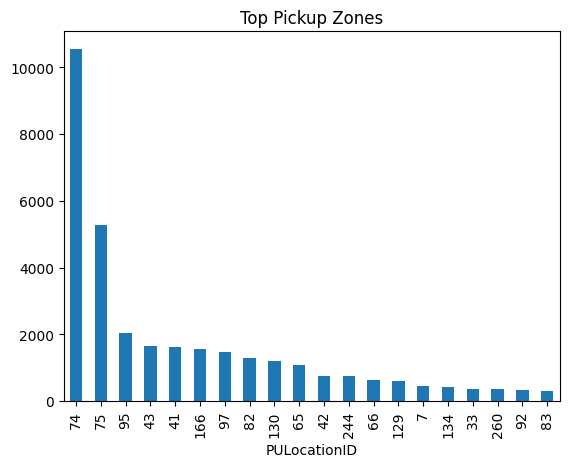

In [46]:
# -------------------------
# ZONE COVERAGE
# -------------------------

print(
    "\nUnique Pickup Zones:"
)

print(
    df['PULocationID'].nunique()
)

df['PULocationID'].value_counts()\
.head(20)\
.plot(kind='bar')

plt.title(
    'Top Pickup Zones'
)

plt.show()

In [48]:
# -------------------------
# DEMAND CREATION
# -------------------------

df['hour_bucket'] = (
    df['lpep_pickup_datetime']
    .dt.floor('h')
)

hourly_demand = (
    df.groupby(
        ['hour_bucket','PULocationID']
    )
    .size()
    .reset_index(
        name='demand'
    )
)
hourly_demand

,hour_bucket,PULocationID,demand
0,2025-12-27 16:00:00,92,1
1,2025-12-27 22:00:00,92,1
2,2025-12-29 00:00:00,92,1
3,2025-12-31 22:00:00,70,1
4,2026-01-01 00:00:00,7,1
...,...,...,...
14061,2026-02-01 16:00:00,130,1
14062,2026-02-01 18:00:00,74,2
14063,2026-02-01 19:00:00,74,2
14064,2026-02-01 20:00:00,74,1


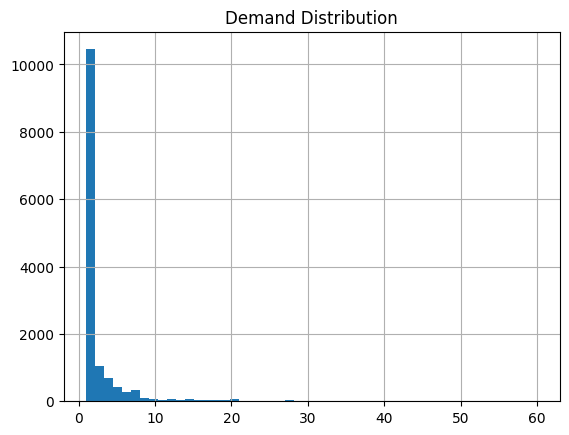

,hour_bucket,PULocationID,demand
0,2025-12-27 16:00:00,92,1
1,2025-12-27 22:00:00,92,1
2,2025-12-29 00:00:00,92,1
3,2025-12-31 22:00:00,70,1
4,2026-01-01 00:00:00,7,1
...,...,...,...
14061,2026-02-01 16:00:00,130,1
14062,2026-02-01 18:00:00,74,2
14063,2026-02-01 19:00:00,74,2
14064,2026-02-01 20:00:00,74,1


In [49]:
# -------------------------
# DEMAND EDA
# -------------------------

hourly_demand['demand'].hist(
    bins=50
)

plt.title(
    "Demand Distribution"
)

plt.show()
hourly_demand

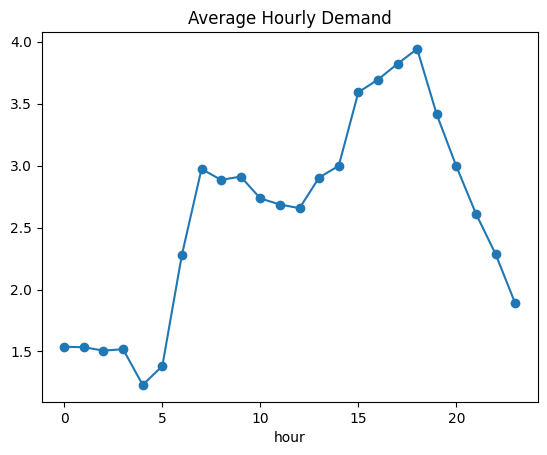

,hour_bucket,PULocationID,demand,hour
0,2025-12-27 16:00:00,92,1,16
1,2025-12-27 22:00:00,92,1,22
2,2025-12-29 00:00:00,92,1,0
3,2025-12-31 22:00:00,70,1,22
4,2026-01-01 00:00:00,7,1,0
...,...,...,...,...
14061,2026-02-01 16:00:00,130,1,16
14062,2026-02-01 18:00:00,74,2,18
14063,2026-02-01 19:00:00,74,2,19
14064,2026-02-01 20:00:00,74,1,20


In [50]:
# Hourly Pattern

hourly_demand['hour'] = (
    hourly_demand['hour_bucket']
    .dt.hour
)

hourly_pattern = (
    hourly_demand
    .groupby('hour')['demand']
    .mean()
)

hourly_pattern.plot(
    marker='o'
)

plt.title(
    "Average Hourly Demand"
)

plt.show()
hourly_demand


In [52]:
# -------------------------
# FEATURE ENGINEERING
# -------------------------

hourly_demand['day_of_week'] = (
    hourly_demand['hour_bucket']
    .dt.dayofweek
)

hourly_demand['month'] = (
    hourly_demand['hour_bucket']
    .dt.month
)

hourly_demand['is_weekend'] = (
    hourly_demand['day_of_week']>=5
).astype(int)

hourly_demand = hourly_demand.sort_values(
    ['PULocationID','hour_bucket']
)

hourly_demand['lag_1'] = (
    hourly_demand.groupby(
        'PULocationID'
    )['demand']
    .shift(1)
)
hourly_demand['lag_24'] = (
    hourly_demand.groupby(
        'PULocationID'
    )['demand']
    .shift(24)
)


In [54]:
hourly_demand['rolling_mean_24'] = (
    hourly_demand.groupby(
        'PULocationID'
    )['demand']
    .transform(
        lambda x:
        x.shift(1)
         .rolling(24)
         .mean()
    )
)

print(hourly_demand.sample(10))

              hour_bucket  PULocationID  demand  hour  day_of_week  month  \
519   2026-01-02 07:00:00            33       1     7            4      1   
55    2026-01-01 01:00:00           130       4     1            3      1   
6586  2026-01-15 12:00:00           116       1    12            3      1   
10720 2026-01-24 04:00:00            75       1     4            5      1   
10791 2026-01-24 09:00:00           127       1     9            5      1   
4797  2026-01-11 20:00:00           129       3    20            6      1   
12082 2026-01-28 10:00:00            28       1    10            2      1   
12450 2026-01-28 22:00:00            75       4    22            2      1   
12860 2026-01-29 17:00:00           196       1    17            3      1   
2223  2026-01-06 09:00:00           116       1     9            1      1   

       is_weekend  lag_1  lag_24  rolling_mean_24  
519             0    1.0     NaN              NaN  
55              0    1.0     NaN              Na